In [9]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
from control import tf, step_response, poles, zeros, pzmap

# Step 1: Define Laplace variable and signals
s = sym.Symbol('s')
u, y = sym.symbols('u y')

In [10]:
# Step 2: Write the system equation in Laplace domain
# Original: 2*s^2*Y + s*Y = s*X + X
lhs = y*(2*s**2 + s)
rhs = u*(s + 1)

In [11]:
# Step 3: Derive transfer function G(s) = Y/U
G_s = sym.simplify(rhs / lhs * y / u)
print("Transfer Function G(s):", G_s)

Transfer Function G(s): (s + 1)/(s*(2*s + 1))


In [12]:
# Step 4: Convert symbolic transfer function to control format
num = sym.Poly(sym.numer(G_s), s).all_coeffs()
den = sym.Poly(sym.denom(G_s), s).all_coeffs()
system = tf([float(c) for c in num], [float(c) for c in den])

print("\nSystem Representation:\n", system)


System Representation:
 <TransferFunction>: sys[3]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s


In [13]:
# Step 5: Show poles and zeros
print("Poles of system:", poles(system))
print("Zeros of system:", zeros(system))

Poles of system: [-0.5+0.j  0. +0.j]
Zeros of system: [-1.+0.j]


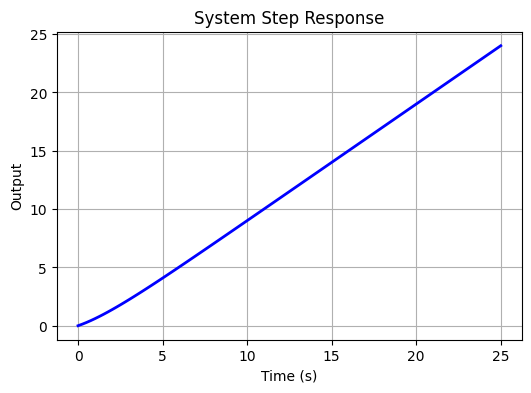

In [14]:
# Step 6: Step response plot
time, response = step_response(system)
plt.figure(figsize=(6,4))
plt.plot(time, response, 'b-', linewidth=2)
plt.title("System Step Response")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.grid(True)
plt.show()

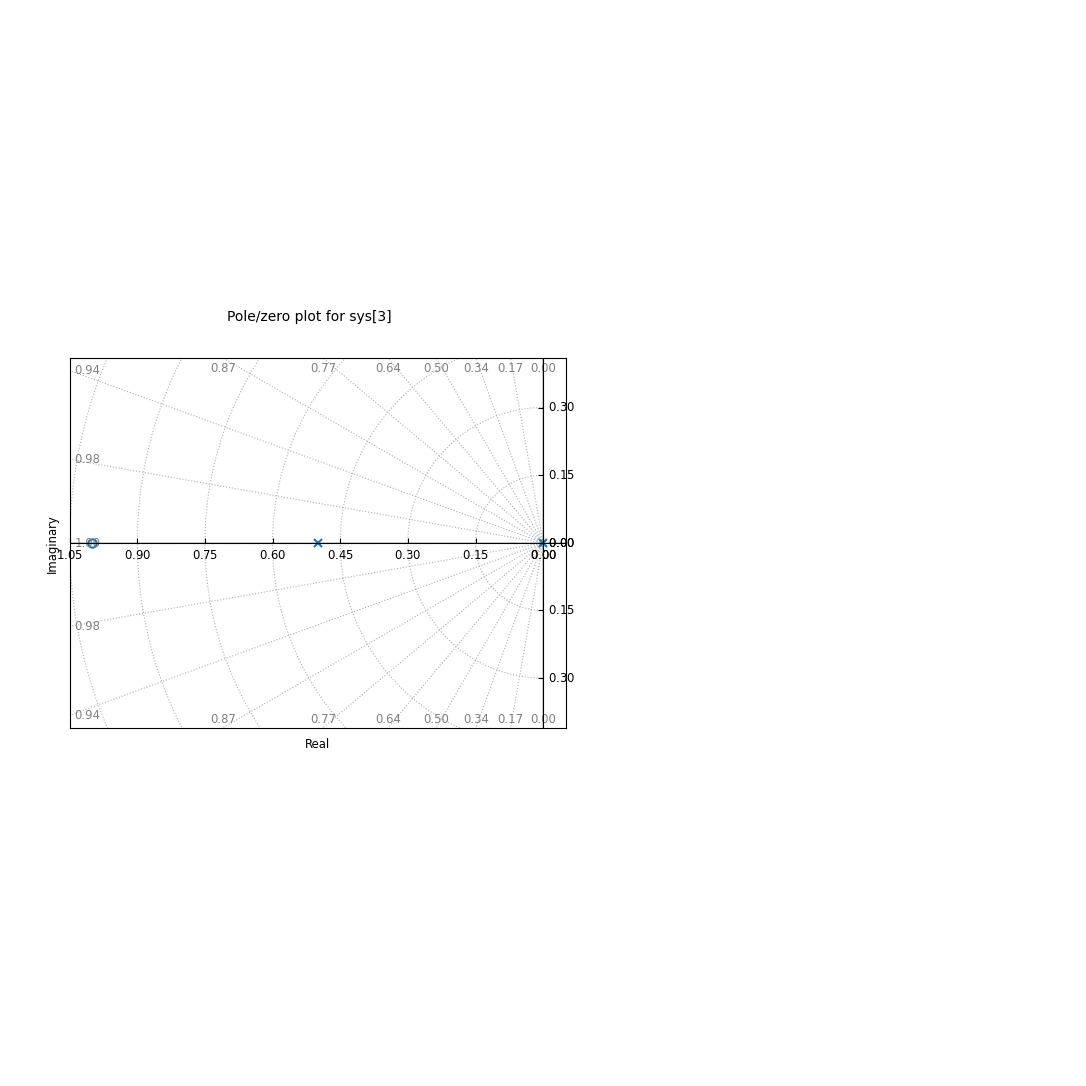

In [15]:
# Step 7: Pole-Zero Map
pzmap(system, grid=True)
plt.show()